In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("student_marks.csv")
df.drop(columns=['Unnamed: 11'],inplace=True)
print(df.head())
df.info()


   Student_ID Student_Name  O/S_marks  WT_marks  DBMS_marks  Python_marks  \
0       10001    Student_1         91        59          42            39   
1       10002    Student_2         85        79          88            86   
2       10003    Student_3         51        38          69            40   
3       10004    Student_4         52        83          75            75   
4       10005    Student_5         48        81          71            35   

   PDP_marks  DSA_marks  OOPs_marks  Total_Marks  Percentage  
0         61         34          36          362       51.71  
1         89         95          73          595       85.00  
2         91         39          46          374       53.43  
3         40         76          93          494       70.57  
4         49         57          87          428       61.14  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------

In [56]:
print("Total Student:",len(df))
print("Average Percentage:",round(df["Percentage"].mean(),2))
print("Highest Percentage",df["Percentage"].max())
print("Lowest Percentage:",df["Percentage"].min())
df["Result"]=np.where(df["Percentage"]>=55,"Pass","Fail")
print(df[["Student_Name","Percentage","Result"]])

Total Student: 200
Average Percentage: 64.21
Highest Percentage 85.0
Lowest Percentage: 48.43
    Student_Name  Percentage Result
0      Student_1       51.71   Fail
1      Student_2       85.00   Pass
2      Student_3       53.43   Fail
3      Student_4       70.57   Pass
4      Student_5       61.14   Pass
..           ...         ...    ...
195  Student_196       56.29   Pass
196  Student_197       65.14   Pass
197  Student_198       70.00   Pass
198  Student_199       60.86   Pass
199  Student_200       78.71   Pass

[200 rows x 3 columns]


In [78]:
#Top 5 Student
top_5=df.sort_values(by="Percentage",ascending=False)
top_5[["Student_Name","Percentage"]].head(5)

,Student_Name,Percentage
1,Student_2,85.00
26,Student_27,85.00
116,Student_117,79.14
199,Student_200,78.71
192,Student_193,78.00


In [42]:
#Subject-wise Average
subject=["O/S_marks","WT_marks","DBMS_marks","Python_marks","PDP_marks","DSA_marks","OOPs_marks"]
avg_marks=df[subject].mean()
print(avg_marks)

O/S_marks       62.395
WT_marks        64.535
DBMS_marks      64.415
Python_marks    64.415
PDP_marks       62.975
DSA_marks       65.240
OOPs_marks      65.520
dtype: float64


In [ ]:
#Fail /Pass Count Show

print(df["Result"].value_counts() )

<bound method IndexOpsMixin.value_counts of 0      Fail
1      Pass
2      Fail
3      Pass
4      Pass
       ... 
195    Pass
196    Pass
197    Pass
198    Pass
199    Pass
Name: Result, Length: 200, dtype: object>


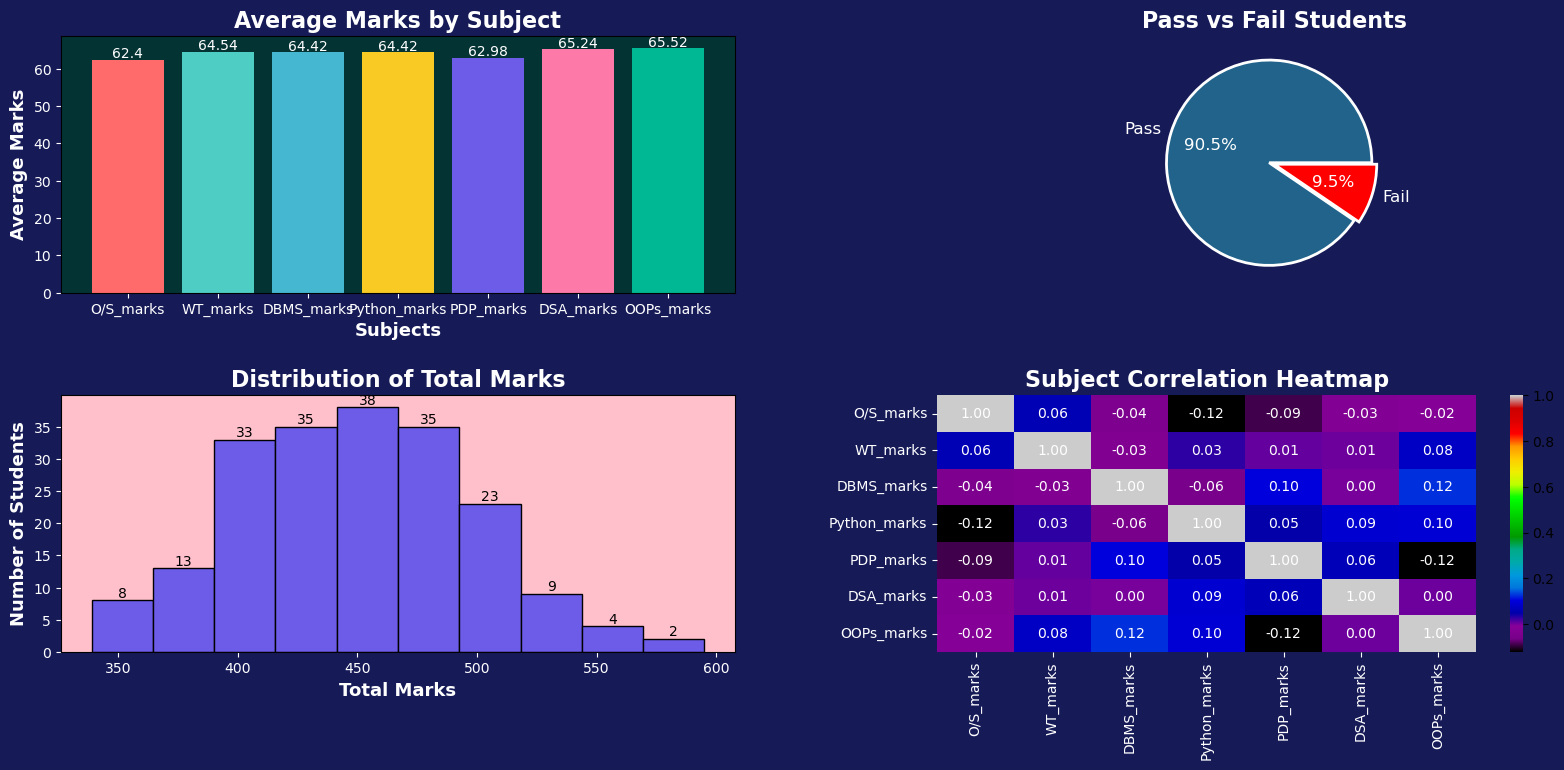

In [148]:
# Visualization(Percetage Distribution)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(20, 8))
fig.patch.set_facecolor("#161B58")
plt.subplots_adjust(
    hspace=0.4,
    wspace=0.3
)

# -------- Bar Chart (Average Marks) --------
avg_marks = df[subject].mean()

colors = ["#FF6B6B","#4ECDC4","#45B7D1",
          "#F9CA24","#6C5CE7","#FD79A8","#00B894"]

bars = ax[0,0].bar(
    avg_marks.index,
    avg_marks.values,
    color=colors
)


# Value dikhayega bar par
for bar in bars:
    height = bar.get_height()
    ax[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,       
        round(height, 2),
        ha="center",
         color="white"
    )

ax[0, 0].set_title("Average Marks by Subject",color="white", fontsize="16" , fontweight="bold")
ax[0, 0].set_xlabel("Subjects",color="white",fontsize="13",fontweight="bold")
ax[0, 0].set_ylabel("Average Marks",color="white",fontsize="13",fontweight="bold")

ax[0,0].tick_params(axis='x', colors='white')
ax[0,0].tick_params(axis='y', colors='white')


#  Pie Chart 


result_count = df["Result"].value_counts()

ax[0, 1].pie(
    result_count,
    labels=result_count.index,
    autopct="%1.1f%%",
    colors=["#21638b", "#ff0000"],
    explode=(0.05,0),
    textprops={
        "color":"white",
        "fontsize":12
    },
    wedgeprops={
        "edgecolor":"white",
        "linewidth":2
    }
)

ax[0, 1].set_title("Pass vs Fail Students",color="white", fontsize=16,fontweight="bold")




# Total Marks Distribution
#Historam Graph

counts,bins,patches=ax[1,0].hist(df["Total_Marks"],
                                 bins=10,
                                 color="#6c5ce7",
                                 edgecolor="black"
                                 )
for count,patch in zip(counts,patches):
    ax[1,0].text(patch.get_x()+patch.get_width()/2,
                 count,
                 int(count),
                 ha="center",
                 va="bottom"
        
    )

ax[1,0].set_title("Distribution of Total Marks", color="white",fontsize="16" , fontweight="bold")
ax[1,0].set_xlabel("Total Marks", color="white",fontsize="13",fontweight="bold")
ax[1,0].set_ylabel("Number of Students", color="white",fontsize="13",fontweight="bold")

ax[1,0].tick_params(axis='x', colors='white')
ax[1,0].tick_params(axis='y', colors='white')



# Heatmap 
# Correlation Matrix
corr_matrix = df[subject].corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    annot_kws={"color":"white"},
    cmap="nipy_spectral",
    fmt=".2f",
    ax=ax[1,1]
)

ax[1,1].set_title("Subject Correlation Heatmap", color="white",fontsize="16" , fontweight="bold")
ax[1,1].tick_params(axis="x",colors="white",)
ax[1,1].tick_params(axis="y",colors="white")

ax[0,0].set_facecolor("#043334")
ax[0,1].set_facecolor("white")
ax[1,0].set_facecolor("pink")
ax[1,1].set_facecolor("red")

plt.show()





